In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import brier_score_loss

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
# Load data 
x_train = pd.read_csv("../data/check/IUBDC 2026/preprocessed_dataset/X_train.csv")
x_test = pd.read_csv("../data/check/IUBDC 2026/preprocessed_dataset/X_test.csv")

y_train = pd.read_csv("../data/check/IUBDC 2026/preprocessed_dataset/y_train.csv")
y_test = pd.read_csv("../data/check/IUBDC 2026/preprocessed_dataset/y_test.csv")

In [3]:
# Preprocessing and scaling for data
numeric_features = x_train.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features)
    ])

# GridSearch to identify best hyperparameters

In [4]:
# AI Code (Not validated)
# =======================

# 1. Define the parameter grid to search over
# Note: Keep the grid relatively small first to see how long it takes to run
param_grid = {
    'xgbclassifier__max_depth': [4, 6, 8],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__subsample': [0.8, 1.0],
    'xgbclassifier__colsample_bytree': [0.8, 1.0],
}

# 2. Initialize the base model (keeping your GPU acceleration)
xgb_base = xgb.XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42,
    eval_metric="auc" # Good practice when evaluating ROC AUC
)

pipe_xgb = make_pipeline(preprocessor, xgb_base)


# 3. Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    scoring='roc_auc',  # Optimize specifically for ROC AUC
    cv=5,               # 5-fold cross-validation
    verbose=2,          # Prints out the progress
    n_jobs=1            # Set to >1 if you want parallel jobs, but with GPU '1' is often safer to avoid memory errors
)

# 4. Fit the grid search to the training data
print("Starting Grid Search...")
grid_search.fit(x_train, y_train.values.ravel())

# 5. Print out the best results
print("\n--- Grid Search Results ---")
print(f"Best ROC AUC Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# 6. Evaluate the best model on your test set
best_model = grid_search.best_estimator_
y_probs_best = best_model.predict_proba(x_test)[:, 1]
y_pred_best = best_model.predict(x_test)

print("\n--- Test Set Performance (Best Model) ---")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_probs_best):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

Starting Grid Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/sebby/miniconda3/envs/iubdc/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:02:10] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329155408/work/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   1.3s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.5s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.4s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.4s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.4s
[CV] END xgbclassifier__colsample_bytree=0.8,

In [5]:
# Check parameters of best model
print(grid_search.best_params_)

{'xgbclassifier__colsample_bytree': 0.8, 'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 6, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__subsample': 1.0}


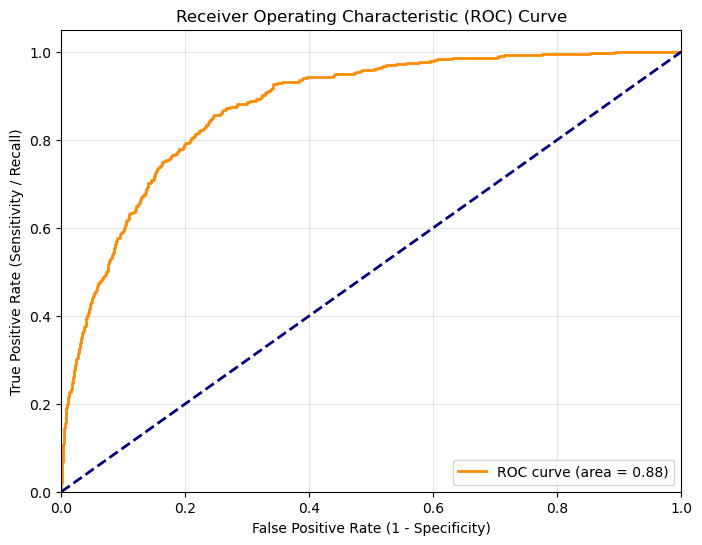

In [6]:
# AI Code (Not validated)
# =======================

# 1. Get the probabilities for the positive class (Class 1)
# Use your best_model or the grid_search.best_estimator_
y_probs = best_model.predict_proba(x_test)[:, 1]

# 2. Calculate the False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Create the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal dashed line

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [7]:
b_score = brier_score_loss(y_test, y_probs)
b_score

0.08945286273956299

This first model optimizes for ROC/AUC, but produces a higher Brier Score

We try again to perform GridSearch while optimizing for Brier Score instead.

In [ ]:
# try performing GridSearch again but optimizing for Brier Score

# 2. Initialize the base model (keeping your GPU acceleration)
xgb_base = xgb.XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42,
    objective="binary:logistic"
)

pipe_xgb = make_pipeline(preprocessor, xgb_base)


# 3. Set up the GridSearchCV
grid_search_brier = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    scoring='neg_brier_score',  # Optimize specifically for brier score
    cv=5,               # 5-fold cross-validation
    verbose=2,          # Prints out the progress
    n_jobs=1            # Set to >1 if you want parallel jobs, but with GPU '1' is often safer to avoid memory errors
)

# 4. Fit the grid search to the training data
print("Starting Grid Search...")
grid_search_brier.fit(x_train, y_train.values.ravel())

# 5. Print out the best results
print("\n--- Grid Search Results ---")
# Multiply by -1 to flip the 'neg_brier_score' back to a standard positive Brier score
print(f"Best Validation Brier Score: {-grid_search_brier.best_score_:.4f}")
print(f"Best Parameters: {grid_search_brier.best_params_}")

# 6. Evaluate the best model on your test set
best_model_brier = grid_search_brier.best_estimator_
y_probs_best_brier = best_model_brier.predict_proba(x_test)[:, 1]
y_pred_best_brier = best_model_brier.predict(x_test)

# Calculate the actual Brier Score for the test set
test_brier = brier_score_loss(y_test, y_probs_best_brier)

print("\n--- Test Set Performance (Best Model) ---")
print(f"Test Brier Score: {test_brier:.4f} (Lower is better, baseline is 0.1204)")
print(f"Test ROC AUC: {roc_auc_score(y_test, y_probs_best_brier):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best_brier):.4f}")
print(classification_report(y_test, y_pred_best_brier))

Starting Grid Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   1.1s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.4s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.5s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclassifier__subsample=0.8; total time=   0.4s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=100, xgbclas

Yields a slightly better Brier Score for a tradeoff in ROC/AUC score


## Model 1 (ROC/AUC)

### Grid Search Results
**Best ROC AUC Score:** 0.8604

### Test Set Performance

| Metric | Score |
|---|---|
| Test ROC AUC | 0.8766 |
| Test Accuracy | 0.8772 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 0 (Negative) | 0.89 | 0.98 | 0.93 | 3,415 |
| 1 (Positive) | 0.68 | 0.30 | 0.42 | 585 |
| **Accuracy** | | | **0.88** | **4,000** |
| Macro Avg | 0.79 | 0.64 | 0.67 | 4,000 |
| Weighted Avg | 0.86 | 0.88 | 0.86 | 4,000 |

## Model 2 (Brier Score)

### Grid Search Results


### Test Set Performance

| Metric | Score | Note |
|---|---|---|
| Test Brier Score | 0.0884 | Lower is better, baseline = 0.1204 |
| Test ROC AUC | 0.8719 | |
| Test Accuracy | 0.8785 | |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 0 (Negative) | 0.89 | 0.97 | 0.93 | 3,415 |
| 1 (Positive) | 0.67 | 0.33 | 0.44 | 585 |
| **Accuracy** | | | **0.88** | **4,000** |
| Macro Avg | 0.78 | 0.65 | 0.69 | 4,000 |
| Weighted Avg | 0.86 | 0.88 | 0.86 | 4,000 |


# Compute SHAP metrics for models

In [17]:
best_model_brier.named_steps['columntransformer']

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{featur

In [42]:
import shap

# 1. Extract your trained XGBoost model from the pipeline
xgb_model = best_model_brier.named_steps['xgbclassifier']

# 2. Preprocess your test data so it matches the model's expected inputs
# (SHAP needs the processed matrix, not the raw dataframe)
x_test_transformed = best_model_brier.named_steps['columntransformer'].transform(x_test)

# Optional: Get the clean feature names from your preprocessor if available
# This keeps your plots readable instead of displaying "col_0", "col_1", etc.
if hasattr(best_model_brier.named_steps['columntransformer'], 'get_feature_names_out'):
    feature_names = best_model_brier.named_steps['columntransformer'].get_feature_names_out()
else:
    feature_names = None

# 3. Initialize SHAP's TreeExplainer (optimized for tree models like XGBoost)
explainer = shap.TreeExplainer(xgb_model,
                               data = x_test_transformed, 
                               feature_perturbation='interventional', 
                               model_output='probability')

# 4. Compute the SHAP values for your transformed test set
# This step automatically utilizes your GPU because the underlying model is set to "cuda"
shap_values = explainer(x_test_transformed)

# If you extracted feature names, map them back to the SHAP object for cleaner plotting
if feature_names is not None:
    shap_values.feature_names = feature_names

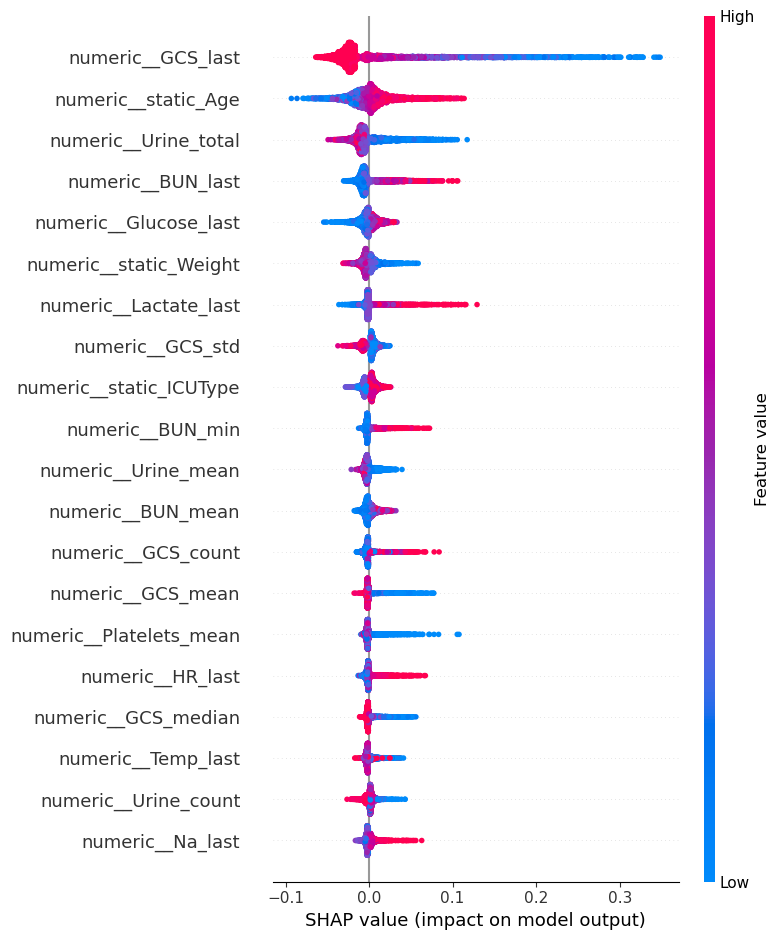

In [43]:
# Plots feature importance with color coding (Red = High feature value, Blue = Low)
shap.summary_plot(shap_values, x_test_transformed, feature_names=feature_names)

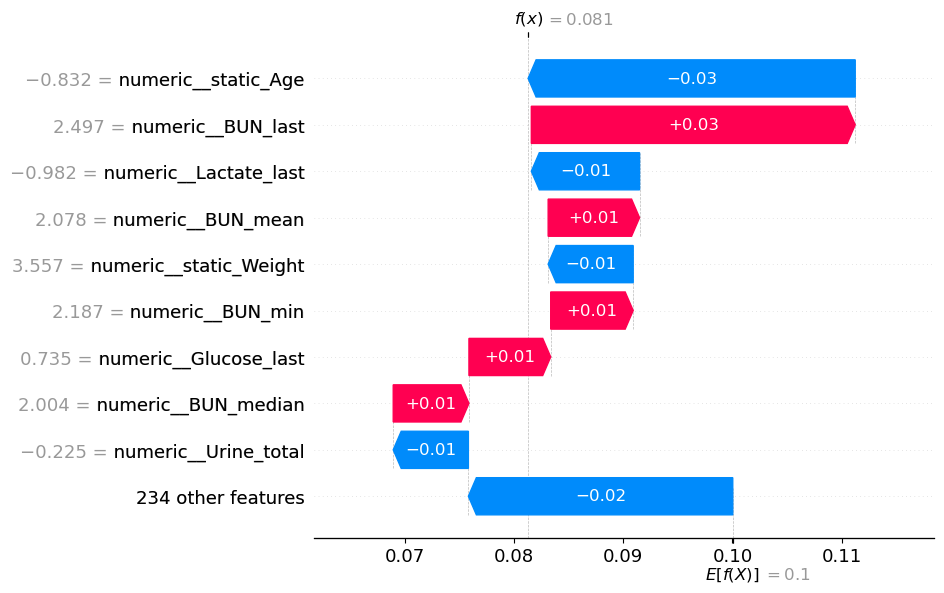

In [48]:
shap.plots.waterfall(shap_values[10])

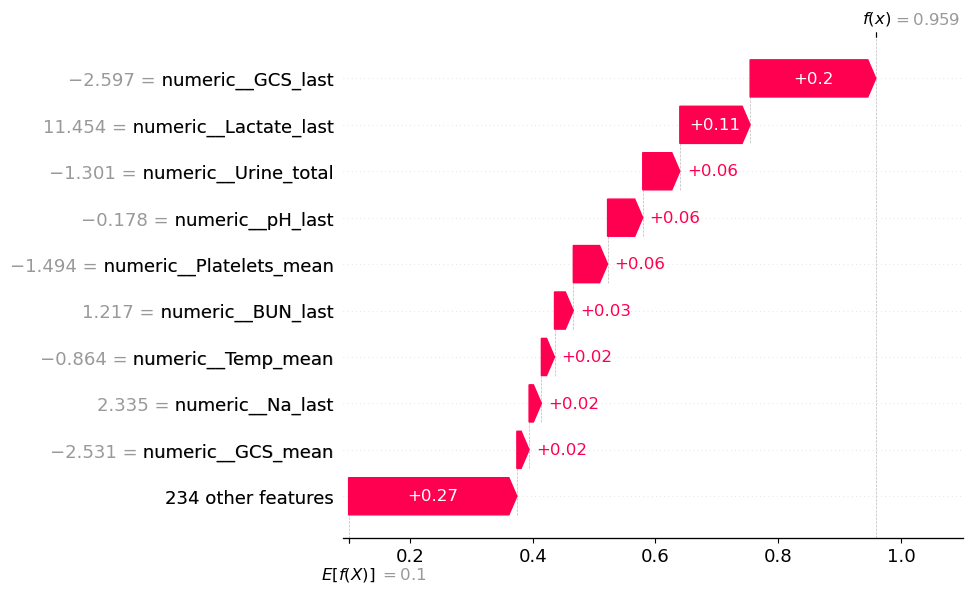

In [ ]:
shap.plots.waterfall(shap_values[213])

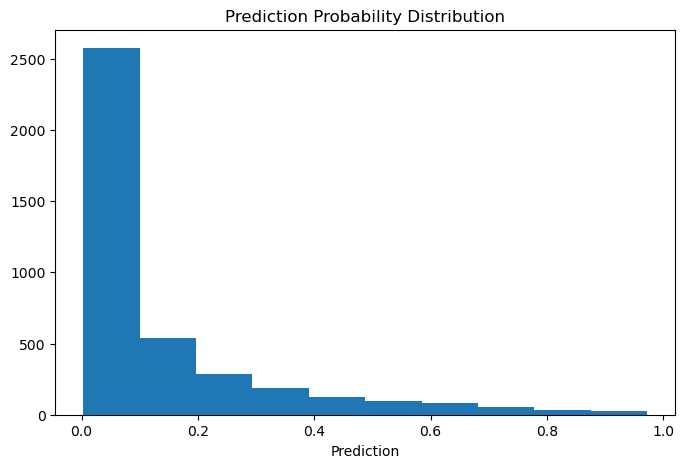

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(y_probs_best_brier)

plt.title("Prediction Probability Distribution")
plt.xlabel("Prediction")

plt.show()

In [37]:
indicies = np.where(y_probs_best_brier > 0.8)[0]
indicies

array([ 213,  290,  325,  397,  477,  496,  500,  581,  680,  693,  737,
        785,  842,  870, 1036, 1058, 1124, 1214, 1237, 1392, 1403, 1494,
       1534, 1571, 1643, 1714, 1742, 1754, 1774, 1902, 1908, 2250, 2329,
       2517, 2694, 2753, 2769, 2796, 2830, 2908, 2927, 3047, 3058, 3250,
       3315, 3316, 3529, 3590, 3616, 3724, 3806, 3910, 3929, 3985])

In [49]:
import numpy as np
from scipy.stats import spearmanr
import pandas as pd

def false_explanation_rate(xgb_model, x_test_transformed, 
                           n_perturbations=10, 
                           noise_std=0.05, 
                           threshold=0.8):
    """
    Perturbs each patient's features slightly and checks
    whether SHAP feature rankings remain stable.
    """
    explainer = shap.TreeExplainer(xgb_model)
    base_shap  = explainer.shap_values(x_test_transformed)
    
    unstable    = 0
    patient_scores = []
    
    for i in range(len(x_test_transformed)):
        correlations = []
        
        for _ in range(n_perturbations):
            # Add tiny Gaussian noise to this patient's features
            x_perturbed = (x_test_transformed[i] + 
                           np.random.normal(0, noise_std, 
                                            x_test_transformed[i].shape))
            
            # Recompute SHAP for the perturbed patient
            perturbed_shap = explainer.shap_values(
                x_perturbed.reshape(1, -1)
            )[0]
            
            # Rank correlation between original and perturbed SHAP
            corr, _ = spearmanr(base_shap[i], perturbed_shap)
            correlations.append(corr)
        
        avg_corr = np.mean(correlations)
        patient_scores.append(avg_corr)
        
        if avg_corr < threshold:
            unstable += 1
    
    fer = unstable / len(x_test_transformed)
    return fer, np.array(patient_scores)


fer, patient_scores = false_explanation_rate(
    xgb_model, x_test_transformed
)
print(f"False Explanation Rate: {fer:.2%}")

False Explanation Rate: 0.25%


In [54]:
import joblib
joblib.dump(best_model_brier, "../ml/models/best_pipeline_brier.joblib")
joblib.dump(best_model, "../ml/models/best_pipeline.joblib")


['../ml/models/best_pipeline.joblib']